In [26]:
#!/usr/bin/env python3

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import simdjson as json
import shapely
from tqdm.auto import tqdm
import time
from osm2geojson import json2shapes
import geopandas as gpd
import pandas as pd

s = time.time()
churches = gpd.read_parquet("churches.parquet")
churches["type"] = "churches"
schools = gpd.read_parquet("schools.parquet")
schools["type"] = "schools"
townhalls = gpd.read_parquet("townhalls.parquet")
townhalls["type"] = "townhalls"
df = gpd.GeoDataFrame(pd.concat([churches, schools, townhalls]))
print(f"Loaded data in {time.time() - s} seconds")

Loaded data in 5.896458148956299 seconds


In [39]:
relations = json.load(open(f"churches_relations.json"))
print(f'parsed {len(json2shapes(relations))} / {len(relations["elements"])}')

Failed to convert relation to shape: 
 AttributeError("'NoneType' object has no attribute 'is_valid'") {'bounds': {'maxlat': 30.3399702,
            'maxlon': -81.4632656,
            'minlat': 30.3384456,
            'minlon': -81.4655229},
 'id': 6793221,
 'members': [{'geometry': [{'lat': 30.3388005, 'lon': -81.4638218},
                           {'lat': 30.3389054, 'lon': -81.4638825},
                           {'lat': 30.3392644, 'lon': -81.4632656},
                           {'lat': 30.3394338, 'lon': -81.463317},
                           {'lat': 30.3397322, 'lon': -81.4640087},
                           {'lat': 30.3397766, 'lon': -81.4642657},
                           {'lat': 30.3399702, 'lon': -81.4644153},
                           {'lat': 30.3397524, 'lon': -81.4647097},
                           {'lat': 30.3397403, 'lon': -81.4650462},
                           {'lat': 30.3396435, 'lon': -81.4650836},
                           {'lat': 30.339587, 'lon': -81.465462

parsed 8395 / 8689


In [27]:
bounds = list(map(float, "-90,-180,90,180".split(",")))

In [30]:
filtered_data = df[
    df["lng"].between(bounds[0], bounds[2]) &
    df["lat"].between(bounds[1], bounds[3])
]

In [31]:
filtered_df = df.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

In [13]:
data = df
limit = 100000
filtered_data = data[
  data["lng"].between(bounds[0], bounds[2]) &
  data["lat"].between(bounds[1], bounds[3])
]
if len(filtered_data) > limit:
  filtered_data = filtered_data.sample(limit)

In [20]:
df.religion.value_counts().head(8).index

Index(['christian', 'muslim', 'buddhist', 'hindu', 'shinto', 'taoist',
       'jewish', 'sikh'],
      dtype='object')

<Axes: >

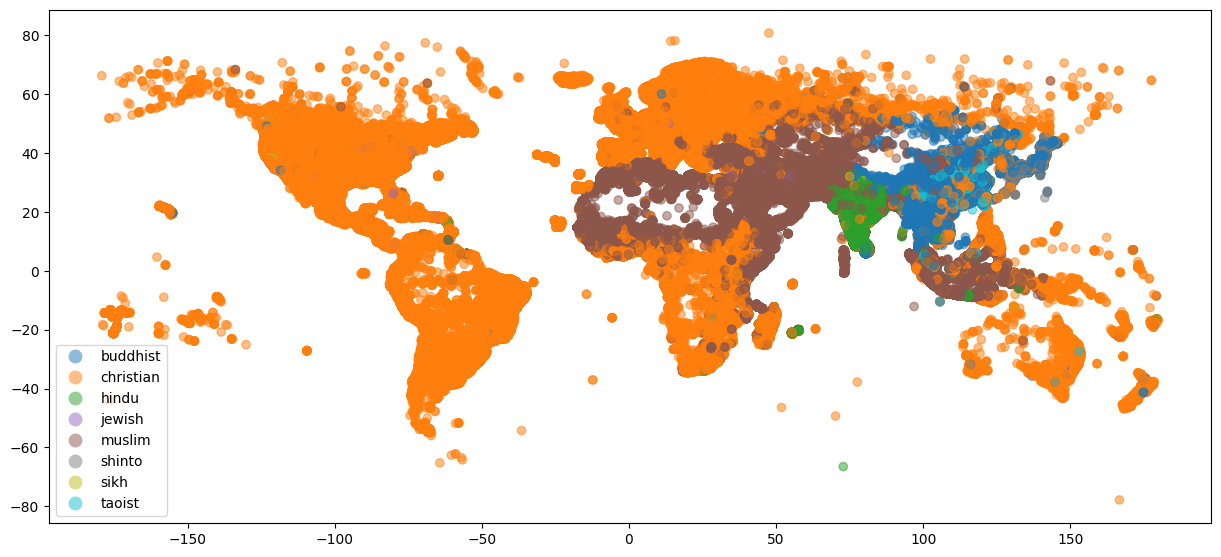

In [25]:
df[df.religion.isin(df.religion.value_counts().head(8).index)].plot("religion", legend=True, figsize=(15,15), alpha=.5)